<a href="https://colab.research.google.com/github/hoshi-3104-com/california-house-price-competition/blob/main/notebooks/07_house_price_model_improve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# driveのマウント
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### モデル学習の準備

In [ ]:
!pip install catboost

In [ ]:
!pip install optuna

!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00


In [ ]:
# 1. ライブラリ・モジュールのインポート
%matplotlib inline
import json
import os
import sys
import warnings
import pickle
from pathlib import Path
from google.colab import drive
from lightgbm import LGBMRegressor
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from xgboost import XGBRegressor

# パスの設定（pathlibを使用してスマートに管理）
COMPETITION_DIR = Path('/content/drive/MyDrive/house_price_competion_hoshino')
if str(COMPETITION_DIR) not in sys.path:
    sys.path.append(str(COMPETITION_DIR))

from my_feature_utils import feature_master, print_feature_directory
from model_tuning_utils import tune_lgbm_parameters, tune_xgboost_parameters, tune_catboost_parameters

# 2. 環境設定・定数定義
warnings.filterwarnings('ignore')

# Kaggle APIの設定
kaggle_json_path = COMPETITION_DIR / 'kaggle.json'
if kaggle_json_path.exists():
    with open(kaggle_json_path, 'r') as f:
        kaggle_data = json.load(f)
    os.environ['KAGGLE_USERNAME'] = kaggle_data['username']
    os.environ['KAGGLE_KEY'] = kaggle_data['key']

# =====================================================================
# 3. データの読み込みと前処理
# =====================================================================
print("--- データの読み込み ---")
train = pd.read_csv(COMPETITION_DIR / '2_preprocess_train_data_add_feature.csv')
test = pd.read_csv(COMPETITION_DIR / '1_preprocess_test_data_add_feature.csv')
sample = pd.read_csv(COMPETITION_DIR / 'sample_raw.csv')

train['geo_cluster'] = train['geo_cluster'].astype('category')
test['geo_cluster'] = test['geo_cluster'].astype('category')

# 最適化パラメータのロード
with open(COMPETITION_DIR / 'all_lgbm_best_params.json', 'r') as f:
    lgbm_best_params = json.load(f)

# 最適化パラメータのロード
with open(COMPETITION_DIR / 'all_xgb_best_params.json', 'r') as f:
    xgb_best_params = json.load(f)

# 最適化パラメータのロード
with open(COMPETITION_DIR / 'best_params_lgbm_log.json', 'r') as f:
    lgbm_best_params_log = json.load(f)

# 4. モデリング用データの作成（X, y）
# Stratified K-Fold用のビン作成
train['Price_bin'] = pd.qcut(train['Price'], q=10, labels=False, duplicates='drop')

# 不要なカラムの削除と特徴量の分離
drop_cols = ["Price", "Log_Price", "BoxCox_Price", "Price_bin", "id"]
X_all_train = train.drop(columns=drop_cols, errors='ignore')
y_all_train = train["Price"]

# テストデータの列順を訓練データに同期
X_test_selected = test[X_all_train.columns]

# 整合性チェック
assert list(X_all_train.columns) == list(X_test_selected.columns), "訓練データとテストデータの列順が一致しません。"

print("\n" + "="*50)
print("🚀 学習準備完了")
print(f"特徴量数: {X_all_train.shape[1]}")
print(f"X_train: {X_all_train.shape} | X_test: {X_test_selected.shape}")
print("="*50)

--- データの読み込み ---

🚀 学習準備完了
特徴量数: 117
X_train: (16512, 117) | X_test: (4128, 117)


In [ ]:
print(xgb_best_params)

{'n_estimators': 390, 'learning_rate': 0.061411370954207276, 'max_depth': 8, 'min_child_weight': 10.283688308938988, 'subsample': 0.8899626761406586, 'colsample_bytree': 0.6404361588301687, 'alpha': 4.8224875510116005, 'reg_lambda': 4.448879079096561, 'random_state': 42, 'verbosity': 0}


学習に使用する総特徴量数: 116

--- 3つのモデルの同時学習と交差検証を開始 ---
--- Fold 1 / 5 開始 ---
--- Fold 2 / 5 開始 ---
--- Fold 3 / 5 開始 ---
--- Fold 4 / 5 開始 ---
--- Fold 5 / 5 開始 ---

① LightGBM       単体OOF RMSE: 0.4159
② XGBoost        単体OOF RMSE: 0.4137
③ LightGBM(Log) 単体OOF RMSE: 0.4183

--- 特徴量重要度とSHAP値の集計・保存を開始 ---
✅ 特徴量重要度(CSV)とSHAP値(npy)の保存が完了しました！

--- SHAP Summary Plot (LightGBM通常版) を出力します ---


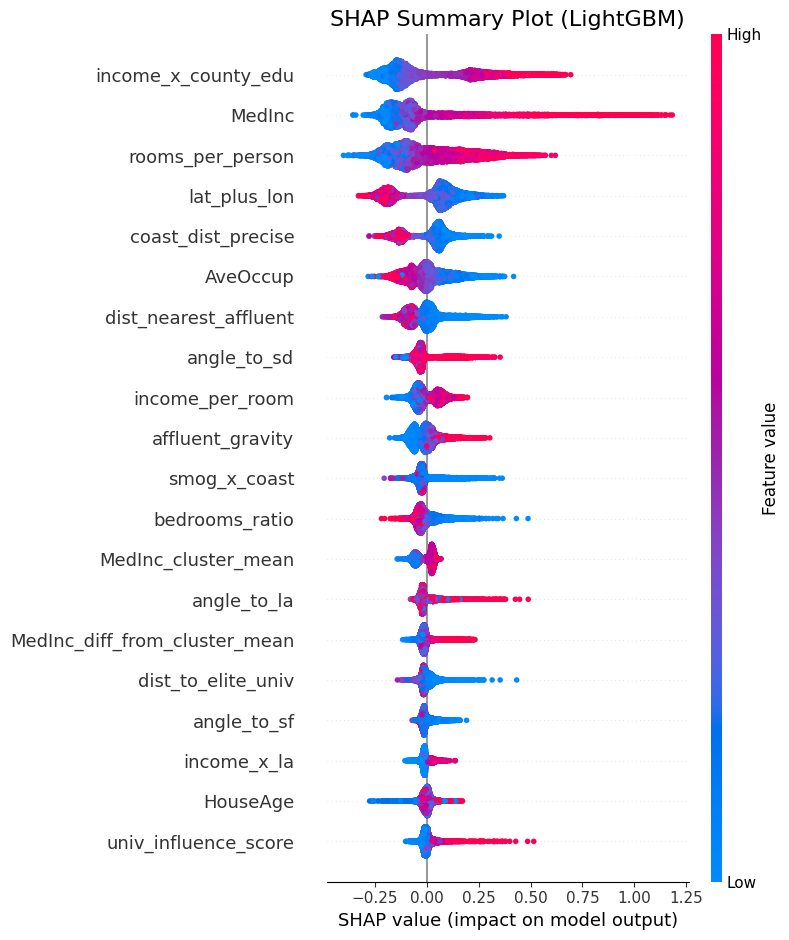


--- Optunaによる最適なブレンド重み(3モデル)の探索を開始 ---
🎉 最適な重みが決定しました！
・LightGBM      重み: 0.3169
・XGBoost       重み: 0.4382
・LightGBM(Log) 重み: 0.2448
🔥 最適化後のブレンドOOF RMSE: 0.4099
✅ 3モデルの最適化ブレンドファイルを保存しました。

--- 第2ステージ：メタモデル（Ridge回帰）によるスタッキングを開始 ---

各Foldの平均メタRMSE: 0.4095
👑 2段目スタッキング(Ridge) 全体OOF RMSE: 0.4098

--- メタモデル（Ridge）における各モデルの寄与度（標準化回帰係数） ---
・xgb_oof       : 係数  0.4623 (絶対値: 0.4623)
・lgbm_oof      : 係数  0.3206 (絶対値: 0.3206)
・lgbm_log_oof  : 係数  0.2962 (絶対値: 0.2962)

🔥 最も最終予測に寄与しているモデル: 【xgb_oof】
✅ スタッキング提出ファイルを『submission_stacking_ridge.csv』として保存しました。

--- チームブレンド用（2段目スタッキング）の予測値保存 ---
✅ 『stacking_ridge_oof.csv』および『stacking_ridge_pred.csv』の保存が完了しました！


In [ ]:
# =====================================================================
# 1. ライブラリのインポート
# =====================================================================
import pickle
import warnings
from pathlib import Path
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt # 追加
import shap # 追加
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# 各種設定
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ベースディレクトリの定義
COMPETITION_DIR = Path('/content/drive/MyDrive/house_price_competion_hoshino')

# =====================================================================
# 2. データの読み込みと前処理（通常版＆対数版）
# =====================================================================
train = pd.read_csv(COMPETITION_DIR / '2_preprocess_train_data_add_feature.csv', dtype={'geo_cluster': 'category'})
test = pd.read_csv(COMPETITION_DIR / '1_preprocess_test_data_add_feature.csv', dtype={'geo_cluster': 'category'})
sample = pd.read_csv(COMPETITION_DIR / 'sample_raw.csv')

# 層化K分割用のビン作成
train['Price_bin'] = pd.qcut(train['Price'], q=10, labels=False, duplicates='drop')

# 不要な列の除外と特徴量の分離
drop_cols = ["Price", "Log_Price", "BoxCox_Price", "Price_bin", "id", "Population"]
X_all_train = train.drop(columns=drop_cols, errors='ignore')
y_all_train = train["Price"]
X_test_selected = test[X_all_train.columns]

# --- 対数変換版データの作成 ---
X_all_train_log = X_all_train.copy()
X_test_selected_log = X_test_selected.copy()
y_all_train_log = np.log1p(y_all_train)

# 厳選8特徴量を対数変換
log_features = [
    'total_income_proxy', 'rooms_per_person', 'local_crime_exposure', 'dist_nearest_city',
    'Population', 'Household', 'AveRooms', 'AveOccup'
]
for col in log_features:
    if col in X_all_train_log.columns:
        X_all_train_log[col] = np.log1p(X_all_train_log[col])
        X_test_selected_log[col] = np.log1p(X_test_selected_log[col])

print(f"学習に使用する総特徴量数: {X_all_train.shape[1]}")

# =====================================================================
# 3. 予測値・特徴量重要度・SHAP格納庫の準備と3モデルの学習
# =====================================================================
oof_lgbm = np.zeros(len(X_all_train))
oof_xgb = np.zeros(len(X_all_train))
oof_lgbm_log = np.zeros(len(X_all_train))

preds_lgbm = np.zeros(len(X_test_selected))
preds_xgb = np.zeros(len(X_test_selected))
preds_lgbm_log = np.zeros(len(X_test_selected))

# --- 【新規追加】特徴量重要度（Feature Importance）格納用のDataFrame ---
fi_lgbm = pd.DataFrame(index=X_all_train.columns)
fi_xgb = pd.DataFrame(index=X_all_train.columns)
fi_lgbm_log = pd.DataFrame(index=X_all_train_log.columns)

# --- 【新規追加】SHAP値格納用の配列（全学習データと同じ形状） ---
shap_values_lgbm = np.zeros(X_all_train.shape)
shap_values_xgb = np.zeros(X_all_train.shape)
shap_values_lgbm_log = np.zeros(X_all_train_log.shape)

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)

print("\n--- 3つのモデルの同時学習と交差検証を開始 ---")
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    X_cv_train_log = X_all_train_log.iloc[cv_train_idx]
    X_cv_val_log = X_all_train_log.iloc[cv_val_idx]
    y_cv_train_log = y_all_train_log.iloc[cv_train_idx]

    # Model 1: LightGBM
    model_lgbm = LGBMRegressor(**lgbm_best_params)
    model_lgbm.fit(X_cv_train, y_cv_train)
    oof_lgbm[cv_val_idx] = np.clip(model_lgbm.predict(X_cv_val), 0, 5.00001)
    preds_lgbm += np.clip(model_lgbm.predict(X_test_selected), 0, 5.00001) / folds_num

    # 🌟 LightGBM: FI & SHAP の抽出
    fi_lgbm[f'fold_{fold}'] = model_lgbm.feature_importances_
    explainer_lgbm = shap.TreeExplainer(model_lgbm)
    shap_values_lgbm[cv_val_idx] = explainer_lgbm.shap_values(X_cv_val)

    # Model 2: XGBoost
    model_xgb = XGBRegressor(**xgb_best_params, enable_categorical=True, tree_method='hist')
    model_xgb.fit(X_cv_train, y_cv_train)
    oof_xgb[cv_val_idx] = np.clip(model_xgb.predict(X_cv_val), 0, 5.00001)
    preds_xgb += np.clip(model_xgb.predict(X_test_selected), 0, 5.00001) / folds_num

    # 🌟 XGBoost: FI & SHAP の抽出 (check_additivity=FalseはCat型エラー回避用)
    fi_xgb[f'fold_{fold}'] = model_xgb.feature_importances_
    explainer_xgb = shap.TreeExplainer(model_xgb)
    shap_values_xgb[cv_val_idx] = explainer_xgb.shap_values(X_cv_val, check_additivity=False)

    # Model 3: LightGBM (対数変換版)
    model_lgbm_log = LGBMRegressor(**lgbm_best_params_log)
    model_lgbm_log.fit(X_cv_train_log, y_cv_train_log)
    oof_lgbm_log[cv_val_idx] = np.clip(np.expm1(model_lgbm_log.predict(X_cv_val_log)), 0, 5.00001)
    preds_lgbm_log += np.clip(np.expm1(model_lgbm_log.predict(X_test_selected_log)), 0, 5.00001) / folds_num

    # 🌟 LightGBM(Log): FI & SHAP の抽出
    fi_lgbm_log[f'fold_{fold}'] = model_lgbm_log.feature_importances_
    explainer_lgbm_log = shap.TreeExplainer(model_lgbm_log)
    shap_values_lgbm_log[cv_val_idx] = explainer_lgbm_log.shap_values(X_cv_val_log)

# 単体モデルのスコア評価
rmse_lgbm = np.sqrt(mean_squared_error(y_all_train, oof_lgbm))
rmse_xgb = np.sqrt(mean_squared_error(y_all_train, oof_xgb))
rmse_lgbm_log = np.sqrt(mean_squared_error(y_all_train, oof_lgbm_log))

print("\n==================================")
print(f"① LightGBM       単体OOF RMSE: {rmse_lgbm:.4f}")
print(f"② XGBoost        単体OOF RMSE: {rmse_xgb:.4f}")
print(f"③ LightGBM(Log) 単体OOF RMSE: {rmse_lgbm_log:.4f}")
print("==================================")

# =====================================================================
# 【新規追加】特徴量重要度とSHAP値の集計・保存・可視化
# =====================================================================
print("\n--- 特徴量重要度とSHAP値の集計・保存を開始 ---")

# 1. Feature Importanceの全Fold平均を計算してCSV保存
fi_lgbm['importance_mean'] = fi_lgbm.mean(axis=1)
fi_xgb['importance_mean'] = fi_xgb.mean(axis=1)
fi_lgbm_log['importance_mean'] = fi_lgbm_log.mean(axis=1)

fi_lgbm.sort_values('importance_mean', ascending=False).to_csv(COMPETITION_DIR / 'lgbm_feature_importance.csv')
fi_xgb.sort_values('importance_mean', ascending=False).to_csv(COMPETITION_DIR / 'xgb_feature_importance.csv')
fi_lgbm_log.sort_values('importance_mean', ascending=False).to_csv(COMPETITION_DIR / 'lgbm_log_feature_importance.csv')

# 2. SHAP値（全学習データ分）をあとで再利用できるようにNumPy配列として保存
np.save(COMPETITION_DIR / 'lgbm_shap_values.npy', shap_values_lgbm)
np.save(COMPETITION_DIR / 'xgb_shap_values.npy', shap_values_xgb)
np.save(COMPETITION_DIR / 'lgbm_log_shap_values.npy', shap_values_lgbm_log)

print("✅ 特徴量重要度(CSV)とSHAP値(npy)の保存が完了しました！")

# 3. Notebook上でパッと確認するためのSHAPサマリープロット表示例 (例としてLightGBM通常版)
print("\n--- SHAP Summary Plot (LightGBM通常版) を出力します ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_lgbm, X_all_train, max_display=20, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=16)
plt.tight_layout()
plt.savefig(COMPETITION_DIR / 'lgbm_shap_summary_plot.png')
plt.show()

# =====================================================================
# 4. Optunaによる3モデルブレンド重みの自動最適化
# =====================================================================
print("\n--- Optunaによる最適なブレンド重み(3モデル)の探索を開始 ---")

def objective(trial):
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0 - w_lgbm)
    w_lgbm_log = 1.0 - w_lgbm - w_xgb

    oof_blend = (oof_lgbm * w_lgbm) + (oof_xgb * w_xgb) + (oof_lgbm_log * w_lgbm_log)
    return np.sqrt(mean_squared_error(y_all_train, oof_blend))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_w_lgbm = study.best_params['w_lgbm']
best_w_xgb = study.best_params['w_xgb']
best_w_lgbm_log = 1.0 - best_w_lgbm - best_w_xgb

print("==================================")
print(f"🎉 最適な重みが決定しました！")
print(f"・LightGBM      重み: {best_w_lgbm:.4f}")
print(f"・XGBoost       重み: {best_w_xgb:.4f}")
print(f"・LightGBM(Log) 重み: {best_w_lgbm_log:.4f}")
print(f"🔥 最適化後のブレンドOOF RMSE: {study.best_value:.4f}")
print("==================================")

# =====================================================================
# 5. 最適な重みを用いた最終ブレンド予測と提出
# =====================================================================
final_predictions = (preds_lgbm * best_w_lgbm) + (preds_xgb * best_w_xgb) + (preds_lgbm_log * best_w_lgbm_log)

# 後段のスタッキング等に備えて各OOF/予測値を個別CSV保存
pd.DataFrame({'lgbm_oof': oof_lgbm}).to_csv(COMPETITION_DIR / 'lgbm_oof.csv', index=False)
pd.DataFrame({'xgb_oof': oof_xgb}).to_csv(COMPETITION_DIR / 'xgb_oof.csv', index=False)
pd.DataFrame({'lgbm_log_oof': oof_lgbm_log}).to_csv(COMPETITION_DIR / 'lgbm_log_oof.csv', index=False)

sample["Price"] = final_predictions
sample.to_csv(COMPETITION_DIR / 'submission_optuna_blend_3models.csv', index=False)
print("✅ 3モデルの最適化ブレンドファイルを保存しました。")

# =====================================================================
# 6. 2段目スタッキング：メタモデル（Ridge回帰）
# =====================================================================
print("\n--- 第2ステージ：メタモデル（Ridge回帰）によるスタッキングを開始 ---")

# 1段目モデルの予測値をメタ特徴量として結合
X_meta_train = pd.DataFrame({
    'lgbm_oof': oof_lgbm,
    'xgb_oof': oof_xgb,
    'lgbm_log_oof': oof_lgbm_log
})

X_meta_test = pd.DataFrame({
    'lgbm_oof': preds_lgbm,
    'xgb_oof': preds_xgb,
    'lgbm_log_oof': preds_lgbm_log
})

oof_stacking = np.zeros(len(X_all_train))
preds_stacking = np.zeros(len(X_test_selected))
meta_cv_scores = []

# --- 【新規追加】各モデルの回帰係数（重み）を格納する配列 ---
meta_coefs = np.zeros(X_meta_train.shape[1])

# 交差検証ループ
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_meta_train, train['Price_bin'])):
    X_meta_cv_train, y_meta_cv_train = X_meta_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_meta_cv_val, y_meta_cv_val = X_meta_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    meta_model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0, random_state=42)
    )
    meta_model.fit(X_meta_cv_train, y_meta_cv_train)

    val_p_meta = np.clip(meta_model.predict(X_meta_cv_val), 0, 5.00001)
    oof_stacking[cv_val_idx] = val_p_meta

    preds_stacking += np.clip(meta_model.predict(X_meta_test), 0, 5.00001) / folds_num

    fold_rmse = np.sqrt(mean_squared_error(y_meta_cv_val, val_p_meta))
    meta_cv_scores.append(fold_rmse)

    # 🌟【新規追加】各Foldの回回帰係数を累積（全Fold終了後に平均化）
    # pipelineの 'ridge' ステップから coef_ を取得します
    meta_coefs += meta_model.named_steps['ridge'].coef_ / folds_num

final_stacking_rmse = np.sqrt(mean_squared_error(y_all_train, oof_stacking))
print("\n==================================")
print(f"各Foldの平均メタRMSE: {np.mean(meta_cv_scores):.4f}")
print(f"👑 2段目スタッキング(Ridge) 全体OOF RMSE: {final_stacking_rmse:.4f}")
print("==================================")

# 🌟【新規追加】回帰係数の集計と、最も寄与しているモデルの出力
coef_df = pd.DataFrame({
    'Model': X_meta_train.columns,
    'Coefficient (Weight)': meta_coefs,
    'Absolute_Coefficient': np.abs(meta_coefs)  # 影響度の強さを測るため絶対値を用意
}).sort_values(by='Absolute_Coefficient', ascending=False)

print("\n--- メタモデル（Ridge）における各モデルの寄与度（標準化回帰係数） ---")
for idx, row in coef_df.iterrows():
    print(f"・{row['Model']:13} : 係数 {row['Coefficient (Weight)']: .4f} (絶対値: {row['Absolute_Coefficient']:.4f})")

best_model = coef_df.iloc[0]['Model']
print(f"\n🔥 最も最終予測に寄与しているモデル: 【{best_model}】")
print("==================================")

# 提出用ファイルの保存
sample["Price"] = preds_stacking
sample.to_csv(COMPETITION_DIR / 'submission_stacking_ridge.csv', index=False)
print("✅ スタッキング提出ファイルを『submission_stacking_ridge.csv』として保存しました。")

# -----------------------------------------------------------------
# 【新規追加】チーム合流・ブレンド用の予測値CSV保存
# -----------------------------------------------------------------
print("\n--- チームブレンド用（2段目スタッキング）の予測値保存 ---")

# ① メタモデル（Ridge）の学習時OOF予測結果を保存
pd.DataFrame({'stacking_ridge_oof': oof_stacking}).to_csv(COMPETITION_DIR / 'stacking_ridge_oof.csv', index=False)

# ② メタモデル（Ridge）のテスト用予測結果を保存
pd.DataFrame({'stacking_ridge_pred': preds_stacking}).to_csv(COMPETITION_DIR / 'stacking_ridge_pred.csv', index=False)

print("✅ 『stacking_ridge_oof.csv』および『stacking_ridge_pred.csv』の保存が完了しました！")

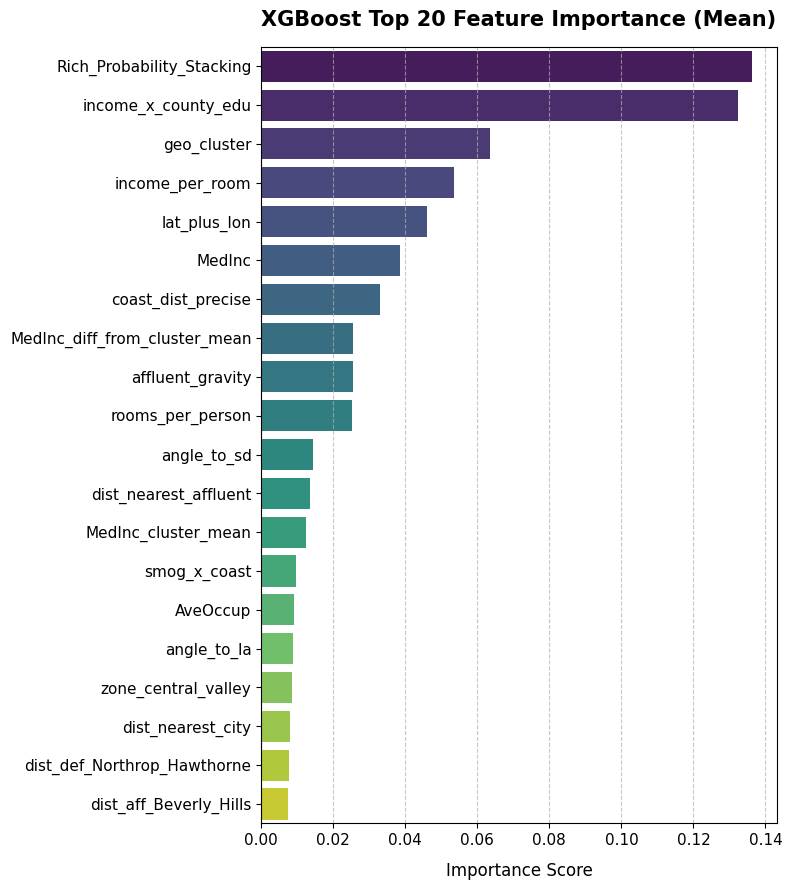

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 特徴量重要度の可視化（Top 10）- 修正版
# =====================================================================

# 1. 描画する上位特徴量の数を指定（10個）
top_n = 20

# 2. 【ココを修正】'importance_mean' 列だけに絞り込んでからソートし、Top 10を抽出
# これにより、列数が確実に「特徴量名」と「重要度」の2列になります
plot_df = fi_xgb[['importance_mean']].sort_values('importance_mean', ascending=False).head(top_n).reset_index()
plot_df.columns = ['Feature', 'Importance']

# 3. グラフの土台を作成（見やすいようにサイズを調整）
fig, ax = plt.subplots(figsize=(8, 9))

# 4. Seabornのbarplotで横棒グラフを描画
sns.barplot(
    x='Importance',
    y='Feature',
    data=plot_df,
    palette='viridis',
    orient='h',
    ax=ax
)

# 5. フォントサイズと見やすさの徹底調整
ax.set_title(f'XGBoost Top {top_n} Feature Importance (Mean)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12, labelpad=10)
ax.set_ylabel('', fontsize=12) # Y軸ラベルを消してスッキリ

# 目盛りの文字サイズを大きくして視認性を確保
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# 6. 縦方向の補助線（点線）を追加
ax.grid(axis='x', linestyle='--', alpha=0.7)

# 7. 全体のレイアウトを綺麗に整えて表示
plt.tight_layout()
plt.show()

#### LightGBMの通常プライス版でのスコア

In [ ]:
# =====================================================================
# 1. ライブラリのインポート
# =====================================================================
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold

# ※必要に応じてパスを有効化してください
# COMPETITION_DIR = Path('/content/drive/MyDrive/house_price_competion_hoshino')

# =====================================================================
# 2. モデル学習と交差検証ループ
# =====================================================================
print("--- ベストパラメータを使用した最終学習とテスト予測を開始 ---")

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test_selected))
cv_scores = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Final Fold {fold + 1} / {folds_num} 開始 ---")

    # データの切り分け
    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    # モデルの学習
    all_lgbm_model = LGBMRegressor(**lgbm_best_params)
    all_lgbm_model.fit(X_cv_train, y_cv_train)

    # 学習済みモデルをpickleで保存
    model_save_path = COMPETITION_DIR / f'all_lgbm_model_fold_{fold + 1}_hoshino.pkl'
    with open(model_save_path, 'wb') as f:
        pickle.dump(all_lgbm_model, f)

    # 検証データの予測とクリッピング
    val_preds = all_lgbm_model.predict(X_cv_val)
    val_preds = np.clip(val_preds, 0, 5.00001)
    oof_predictions[cv_val_idx] = val_preds

    # テストデータの予測とアンサンブル
    test_preds = all_lgbm_model.predict(X_test_selected)
    test_preds = np.clip(test_preds, 0, 5.00001)
    test_predictions += test_preds / folds_num

    # スコア計算
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, val_preds))
    cv_scores.append(fold_rmse)

# =====================================================================
# 3. 最終結果の表示と提出ファイルの準備
# =====================================================================
print("\n==================================")
print(f"最終各Foldの平均スコア: {np.mean(cv_scores):.4f}")
final_oof_score = np.sqrt(mean_squared_error(y_all_train, oof_predictions))
print(f"最終全体のOOFスコア (RMSE): {final_oof_score:.4f}")
print("==================================")

# 提出用ファイルの作成と保存
sample["Price"] = test_predictions
sample.to_csv(COMPETITION_DIR / 'submission_lgbm.csv', index=False)

# =====================================================================
# 4. 【追加】ブレンド・スタッキング用予測値のCSV保存
# =====================================================================
print("\n--- ブレンド・スタッキング用の予測値保存 ---")

# ① 学習時OOF予測結果を保存
pd.DataFrame({'lgbm_oof': oof_predictions}).to_csv(COMPETITION_DIR / 'lgbm_oof.csv', index=False)

# ② テスト用予測結果を保存
pd.DataFrame({'lgbm_pred': test_predictions}).to_csv(COMPETITION_DIR / 'lgbm_pred.csv', index=False)

print("✅ 『lgbm_oof.csv』および『lgbm_pred.csv』の保存が完了しました！")

--- ベストパラメータを使用した最終学習とテスト予測を開始 ---
--- Final Fold 1 / 5 開始 ---
--- Final Fold 2 / 5 開始 ---
--- Final Fold 3 / 5 開始 ---
--- Final Fold 4 / 5 開始 ---
--- Final Fold 5 / 5 開始 ---

最終各Foldの平均スコア: 0.4172
最終全体のOOFスコア (RMSE): 0.4173

--- ブレンド・スタッキング用の予測値保存 ---
✅ 『lgbm_oof.csv』および『lgbm_pred.csv』の保存が完了しました！


In [ ]:
sample.to_csv('submit_house_price_add_features.csv', index=False)

# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_features.csv -m "Yeah! I submit my file through the Google Colab!"

100% 93.8k/93.8k [00:00<00:00, 130kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### **LightGBMのモデルをoptunaでパラメータチューニング&最適値で予測**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.9 MB/s eta 0:00:00


In [ ]:
# --- 自作のLGBMチューニングモジュールから関数をインポート ---
from model_tuning_utils import tune_lgbm_parameters

# 【1行で実行】パラメータの調整からGoogle Driveへの保存までを一括自動処理！
lgbm_best_params = tune_lgbm_parameters(
    X=X_all_train,
    y=y_all_train,
    stratify_bin=train['Price_bin'],
    save_dir=COMPETITION_DIR,
    filename='all_lgbm_best_params.json', # 保存したいファイル名
    n_trials=30                           # 試行回数
)

# --- 4. 最強のパラメータで最終予測 ---
print("--- ベストパラメータを使用した最終学習とテスト予測を開始 ---")

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test_selected))
cv_scores = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Final Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    all_lgbm_model = LGBMRegressor(**lgbm_best_params)
    all_lgbm_model.fit(X_cv_train, y_cv_train)

    val_preds = all_lgbm_model.predict(X_cv_val)
    val_preds = np.clip(val_preds, 0, 5.00001)
    oof_predictions[cv_val_idx] = val_preds

    test_preds = all_lgbm_model.predict(X_test_selected)
    test_preds = np.clip(test_preds, 0, 5.00001)
    test_predictions += test_preds / folds_num

    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, val_preds))
    cv_scores.append(fold_rmse)

print("\n==================================")
print(f"最終各Foldの平均スコア: {np.mean(cv_scores):.4f}")
final_oof_score = np.sqrt(mean_squared_error(y_all_train, oof_predictions))
print(f"最終全体のOOFスコア (RMSE): {final_oof_score:.4f}")
print("==================================")

# 提出用ファイルの作成
sample["Price"] = test_predictions

--- OptunaによるLGBMハイパーパラメータチューニングを開始 (総試行回数: 30) ---


LGBM Tuning:   3%|▎         | 1/30 [00:23<11:23, 23.58s/it, Best RMSE=0.4788]

★ Optuna Trial  1 / 30 完了 | 今回の検証RMSE: 0.4788


LGBM Tuning:   7%|▋         | 2/30 [00:35<07:41, 16.49s/it, Best RMSE=0.4502]

★ Optuna Trial  2 / 30 完了 | 今回の検証RMSE: 0.4502


...

★ Optuna Trial 28 / 30 完了 | 今回の検証RMSE: 0.4303


LGBM Tuning:  97%|█████████▋| 29/30 [08:49<00:17, 17.30s/it, Best RMSE=0.4268]

★ Optuna Trial 29 / 30 完了 | 今回の検証RMSE: 0.4333


LGBM Tuning: 100%|██████████| 30/30 [09:18<00:00, 18.62s/it, Best RMSE=0.4268]


★ Optuna Trial 30 / 30 完了 | 今回の検証RMSE: 0.4273
--- チューニング完了 ---

🏆 ベストOOFスコア (RMSE): 0.4268

✅ 最適パラメータを自動保存しました: /content/drive/MyDrive/house_price_competion_hoshino/all_lgbm_best_params.json

--- ベストパラメータを使用した最終学習とテスト予測を開始 ---
--- Final Fold 1 / 5 開始 ---
--- Final Fold 2 / 5 開始 ---
--- Final Fold 3 / 5 開始 ---
--- Final Fold 4 / 5 開始 ---
--- Final Fold 5 / 5 開始 ---

最終各Foldの平均スコア: 0.4267
最終全体のOOFスコア (RMSE): 0.4268


In [ ]:
sample.to_csv('submit_house_price_add_features_and_stratified_kfold_optuna.csv', index=False)# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_features_and_stratified_kfold_optuna.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.0k/94.0k [00:00<00:00, 509kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### XGBoostでのパラメータチューニング

In [ ]:
# --- 自作のLGBMチューニングモジュールから関数をインポート ---
from model_tuning_utils import tune_xgboost_parameters
import warnings
# すべての警告を完全に非表示にする
warnings.filterwarnings('ignore')

# 【1行で実行】パラメータの調整からGoogle Driveへの保存までを一括自動処理！
best_params = tune_xgboost_parameters(
    X=X_all_train,
    y=y_all_train,
    stratify_bin=train['Price_bin'],
    save_dir=COMPETITION_DIR,
    filename='all_xgb_best_params.json', # 保存したいファイル名
    n_trials=30                           # 試行回数
)
# --- 4. 最強のパラメータで最終予測 ---
print("--- ベストパラメータを使用した最終学習とテスト予測を開始 ---")

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_all_train))
test_predictions = np.zeros(len(X_test_selected))
cv_scores = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Final Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    all_xgb_model = XGBRegressor(**best_params, enable_categorical=True, tree_method='hist')
    all_xgb_model.fit(X_cv_train, y_cv_train)

    val_preds = all_xgb_model.predict(X_cv_val)
    val_preds = np.clip(val_preds, 0, 5.00001)
    oof_predictions[cv_val_idx] = val_preds

    test_preds = all_xgb_model.predict(X_test_selected)
    test_preds = np.clip(test_preds, 0, 5.00001)
    test_predictions += test_preds / folds_num

    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, val_preds))
    cv_scores.append(fold_rmse)

print("\n==================================")
print(f"最終各Foldの平均スコア: {np.mean(cv_scores):.4f}")
final_oof_score = np.sqrt(mean_squared_error(y_all_train, oof_predictions))
print(f"最終全体のOOFスコア (RMSE): {final_oof_score:.4f}")
print("==================================")

# 提出用ファイルの作成
sample["Price"] = test_predictions

--- OptunaによるXGBoostチューニングを開始 (試行回数: 30) ---


XGBoost Tuning:   3%|▎         | 1/30 [00:46<22:16, 46.08s/it, Best RMSE=0.4202]

★ XGBoost Trial  1 / 30 完了 | 検証RMSE: 0.4202


XGBoost Tuning:   7%|▋         | 2/30 [01:16<17:17, 37.07s/it, Best RMSE=0.4202]

★ XGBoost Trial  2 / 30 完了 | 検証RMSE: 0.4274


...

XGBoost Tuning:  97%|█████████▋| 29/30 [41:32<01:15, 75.72s/it, Best RMSE=0.4136]

★ XGBoost Trial 29 / 30 完了 | 検証RMSE: 0.4168


XGBoost Tuning: 100%|██████████| 30/30 [42:08<00:00, 84.29s/it, Best RMSE=0.4136]

★ XGBoost Trial 30 / 30 完了 | 検証RMSE: 0.4308
✅ パラメータを保存しました: /content/drive/MyDrive/house_price_competion_hoshino/all_xgb_best_params.json

--- ベストパラメータを使用した最終学習とテスト予測を開始 ---
--- Final Fold 1 / 5 開始 ---


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:geo_cluster: category

In [ ]:
sample.to_csv('submit_house_price_add_features_and_stratified_kfold_optuna.csv', index=False)

# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_house_price_add_features_and_stratified_kfold_optuna.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.2k/94.2k [00:00<00:00, 132kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### log変換版のLightGBM（目的変数といくつか説明変数をlog変換）

In [ ]:
# =====================================================================
# 1. ライブラリのインポート
# =====================================================================
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold

# =====================================================================
# 2. データのコピーと対数変換 (目的変数 + 厳選8特徴量)
# =====================================================================
X_train_log = X_all_train.copy()
X_test_log = X_test_selected.copy()

# 目的変数の対数変換
y_train_log = np.log1p(y_all_train)

# 対数変換を適用する8つの特徴量リスト
log_features = [
    'total_income_proxy', 'rooms_per_person', 'local_crime_exposure', 'dist_nearest_city',
    'Population', 'Household', 'AveRooms', 'AveOccup'
]

# 特徴量の対数変換を実行
for col in log_features:
    if col in X_train_log.columns:
        X_train_log[col] = np.log1p(X_train_log[col])
        X_test_log[col] = np.log1p(X_test_log[col])

# =====================================================================
# 3. クロスバリデーションの初期化（スタッキングを意識した命名）
# =====================================================================
folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)

# スタッキングに引き継ぐための予測値格納エリア
oof_lgbm_log = np.zeros(len(X_all_train))
test_lgbm_log = np.zeros(len(X_test_selected))
cv_scores = []

# =====================================================================
# 4. モデルの学習と交差検証ループ
# =====================================================================
print("--- LightGBM (対数変換版) の学習と予測を開始 ---")

for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_train_log, train['Price_bin'])):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    # データの切り分け (対数変換済みのデータを使用)
    X_cv_train, y_cv_train = X_train_log.iloc[cv_train_idx], y_train_log.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_train_log.iloc[cv_val_idx], y_train_log.iloc[cv_val_idx]

    # モデルの定義（デフォルトパラメータ）と学習
    model_lgbm_log = LGBMRegressor(**lgbm_best_params)
    model_lgbm_log.fit(X_cv_train, y_cv_train)

    # 学習済みモデルをpickleで別名保存
    model_save_path = COMPETITION_DIR / f'model_lgbm_log_fold_{fold + 1}.pkl'
    with open(model_save_path, 'wb') as f:
        pickle.dump(model_lgbm_log, f)

    # 検証データの予測と元のスケールへの復元 (expm1)
    val_preds_log = model_lgbm_log.predict(X_cv_val)
    val_preds_original = np.expm1(val_preds_log)
    val_preds_original = np.clip(val_preds_original, 0, 5.00001)
    oof_lgbm_log[cv_val_idx] = val_preds_original

    # テストデータの予測と元のスケールへの復元 (expm1) + アンサンブル
    test_preds_log = model_lgbm_log.predict(X_test_log)
    test_preds_original = np.expm1(test_preds_log)
    test_preds_original = np.clip(test_preds_original, 0, 5.00001)
    test_lgbm_log += test_preds_original / folds_num

    # 変換前の「本来の y」と比較して各FoldのRMSEを算出
    fold_rmse = np.sqrt(mean_squared_error(y_all_train.iloc[cv_val_idx], val_preds_original))
    cv_scores.append(fold_rmse)
    print(f"Fold {fold + 1} RMSE: {fold_rmse:.4f}")

# =====================================================================
# 5. 最終結果の表示とスタッキング用データのローカル保存
# =====================================================================
print("\n==================================")
print(f"各Foldの平均RMSE: {np.mean(cv_scores):.4f}")
final_oof_score = np.sqrt(mean_squared_error(y_all_train, oof_lgbm_log))
print(f"最終全体のOOF RMSE: {final_oof_score:.4f}")
print("==================================")

print("\n--- 次のスタッキングステージ用ファイルを保存 ---")

# 訓練データ用のOOF予測を保存
oof_df = pd.DataFrame({'lgbm_log_oof': oof_lgbm_log})
oof_df.to_csv(COMPETITION_DIR / 'lgbm_log_oof_predictions.csv', index=False)

# テストデータ用の予測を保存
test_pred_df = pd.DataFrame({'lgbm_log_pred': test_lgbm_log})
test_pred_df.to_csv(COMPETITION_DIR / 'lgbm_log_test_predictions.csv', index=False)

print("✅ パラメータ・モデル・予測値のすべての保存が完了しました。")

--- LightGBM (対数変換版) の学習と予測を開始 ---
--- Fold 1 / 5 開始 ---
Fold 1 RMSE: 0.4247
--- Fold 2 / 5 開始 ---
Fold 2 RMSE: 0.4163
--- Fold 3 / 5 開始 ---
Fold 3 RMSE: 0.4131
--- Fold 4 / 5 開始 ---
Fold 4 RMSE: 0.4261
--- Fold 5 / 5 開始 ---
Fold 5 RMSE: 0.4156

各Foldの平均RMSE: 0.4192
最終全体のOOF RMSE: 0.4192

--- 次のスタッキングステージ用ファイルを保存 ---
✅ パラメータ・モデル・予測値のすべての保存が完了しました。


log変換版LightGBMのパラメータチューニング

In [ ]:
# =====================================================================
# 1. ライブラリ・モジュールのインポート
# =====================================================================
import json
import os
import numpy as np
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

# Optunaのログ出力を抑制してすっきりさせる
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =====================================================================
# 2. 対数変換版 LightGBM チューニング関数
# =====================================================================
def tune_lgbm_log_parameters(X_log, y_log, y_original, stratify_bin, save_dir, filename='best_params_lgbm_log.json', n_trials=30, random_state=42):
    """
    X_log: 対数変換済みの説明変数
    y_log: 対数変換済みの目的変数
    y_original: 元のスケール（変換前）の目的変数 (正しくRMSEを評価するため)
    """
    def objective(trial):
        # 対数変換データ向けに探索範囲を最適化
        params = {
            'random_state': random_state,
            'verbose': -1,
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15),  # 少し高めを許容
            'max_depth': trial.suggest_int('max_depth', 3, 8),                  # 少し浅めにシフト
            'num_leaves': trial.suggest_int('num_leaves', 7, 63),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-5, 5.0, log=True), # 下限を広く
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-5, 5.0, log=True), # 下限を広く
        }

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        oof_preds = np.zeros(len(X_log))

        for cv_train_idx, cv_val_idx in skf.split(X_log, stratify_bin):
            # 対数変換済みのデータで切り分け
            X_cv_train, y_cv_train = X_log.iloc[cv_train_idx], y_log.iloc[cv_train_idx]
            X_cv_val = X_log.iloc[cv_val_idx]

            # モデルの学習
            model = LGBMRegressor(**params)
            model.fit(X_cv_train, y_cv_train)

            # 【重要】予測値を expm1 で元のスケールに復元してから格納
            preds_log = model.predict(X_cv_val)
            preds_original = np.expm1(preds_log)
            oof_preds[cv_val_idx] = np.clip(preds_original, 0, 5.00001)

        # 評価は「元のスケールのy」で行うことで、コンペの評価指標と完全一致させる
        trial_rmse = np.sqrt(mean_squared_error(y_original, oof_preds))
        tqdm.write(f"★ LGBM(Log) Trial {trial.number + 1:2d} / {n_trials} 完了 | 検証RMSE: {trial_rmse:.4f}")
        return trial_rmse

    print(f"--- OptunaによるLightGBM(対数版)チューニングを開始 (試行回数: {n_trials}) ---")
    study = optuna.create_study(direction='minimize')
    pbar = tqdm(range(n_trials), desc="LGBM Log Tuning")

    for _ in pbar:
        study.optimize(objective, n_trials=1, n_jobs=1)
        pbar.set_postfix({"Best RMSE": f"{study.best_value:.4f}"})

    best_params = study.best_params
    best_params['random_state'] = random_state
    best_params['verbose'] = -1

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)
    with open(save_path, 'w') as f:
        json.dump(best_params, f, indent=4)

    print(f"✅ 対数版パラメータを保存しました: {save_path}\n")
    return best_params

# 関数を呼び出してチューニングを実行
lgbm_log_best_params = tune_lgbm_log_parameters(
    X_log=X_train_log,          # 対数変換した特徴量
    y_log=y_train_log,          # 対数変換した目的変数
    y_original=y_all_train,     # 【重要】元のスケールの目的変数（評価用）
    stratify_bin=train['Price_bin'],
    save_dir=COMPETITION_DIR
)

--- OptunaによるLightGBM(対数版)チューニングを開始 (試行回数: 30) ---


LGBM Log Tuning:   0%|          | 0/30 [00:00<?, ?it/s]

★ LGBM(Log) Trial  1 / 30 完了 | 検証RMSE: 0.4349
★ LGBM(Log) Trial  2 / 30 完了 | 検証RMSE: 0.4345
★ LGBM(Log) Trial  3 / 30 完了 | 検証RMSE: 0.4292
★ LGBM(Log) Trial  4 / 30 完了 | 検証RMSE: 0.4269
★ LGBM(Log) Trial  5 / 30 完了 | 検証RMSE: 0.4341
★ LGBM(Log) Trial  6 / 30 完了 | 検証RMSE: 0.4224
★ LGBM(Log) Trial  7 / 30 完了 | 検証RMSE: 0.4212
★ LGBM(Log) Trial  8 / 30 完了 | 検証RMSE: 0.4479
★ LGBM(Log) Trial  9 / 30 完了 | 検証RMSE: 0.4218
★ LGBM(Log) Trial 10 / 30 完了 | 検証RMSE: 0.4149
★ LGBM(Log) Trial 11 / 30 完了 | 検証RMSE: 0.4297
★ LGBM(Log) Trial 12 / 30 完了 | 検証RMSE: 0.4192
★ LGBM(Log) Trial 13 / 30 完了 | 検証RMSE: 0.4200
★ LGBM(Log) Trial 14 / 30 完了 | 検証RMSE: 0.4247
★ LGBM(Log) Trial 15 / 30 完了 | 検証RMSE: 0.4231
★ LGBM(Log) Trial 16 / 30 完了 | 検証RMSE: 0.4198
★ LGBM(Log) Trial 17 / 30 完了 | 検証RMSE: 0.4204
★ LGBM(Log) Trial 18 / 30 完了 | 検証RMSE: 0.4339
★ LGBM(Log) Trial 19 / 30 完了 | 検証RMSE: 0.4180
★ LGBM(Log) Trial 20 / 30 完了 | 検証RMSE: 0.4185
★ LGBM(Log) Trial 21 / 30 完了 | 検証RMSE: 0.4183
★ LGBM(Log) Trial 22 / 30 完了 | 検証R

#### 単体lightGBM XGBoost log変換後のlightGBMの3モデルでブレンド

・各モデルの重みはOptunaで最適値を探索

In [ ]:
# =====================================================================
# 1. ライブラリのインポート
# =====================================================================
import pickle
import warnings
from pathlib import Path
import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBRegressor

# 各種設定
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ベースディレクトリの定義
COMPETITION_DIR = Path('/content/drive/MyDrive/house_price_competion_hoshino')

# =====================================================================
# 2. データの読み込みと前処理（通常版＆対数版）
# =====================================================================
train = pd.read_csv(COMPETITION_DIR / '2_preprocess_train_data_add_feature.csv', dtype={'geo_cluster': 'category'})
test = pd.read_csv(COMPETITION_DIR / '1_preprocess_test_data_add_feature.csv', dtype={'geo_cluster': 'category'})
sample = pd.read_csv(COMPETITION_DIR / 'sample_raw.csv')

# 層化K分割用のビン作成
train['Price_bin'] = pd.qcut(train['Price'], q=10, labels=False, duplicates='drop')

# 不要な列の除外と特徴量の分離
drop_cols = ["Price", "Log_Price", "BoxCox_Price", "Price_bin", "id", "Population", "proximity_to_coast"]
X_all_train = train.drop(columns=drop_cols, errors='ignore')
y_all_train = train["Price"]
X_test_selected = test[X_all_train.columns]

# --- 【追加】対数変換版データの作成 ---
X_all_train_log = X_all_train.copy()
X_test_selected_log = X_test_selected.copy()
y_all_train_log = np.log1p(y_all_train)

# 厳選8特徴量を対数変換
log_features = [
    'total_income_proxy', 'rooms_per_person', 'local_crime_exposure', 'dist_nearest_city',
    'Population', 'Household', 'AveRooms', 'AveOccup'
]
for col in log_features:
    if col in X_all_train_log.columns:
        X_all_train_log[col] = np.log1p(X_all_train_log[col])
        X_test_selected_log[col] = np.log1p(X_test_selected_log[col])

print(f"学習に使用する総特徴量数: {X_all_train.shape[1]}")

# =====================================================================
# 3. 予測値格納庫の準備と3モデルの学習
# =====================================================================
oof_lgbm = np.zeros(len(X_all_train))
oof_xgb = np.zeros(len(X_all_train))
oof_lgbm_log = np.zeros(len(X_all_train))  # 対数版の格納庫

preds_lgbm = np.zeros(len(X_test_selected))
preds_xgb = np.zeros(len(X_test_selected))
preds_lgbm_log = np.zeros(len(X_test_selected))  # 対数版の格納庫

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)

print("\n--- 3つのモデルの同時学習と交差検証を開始 ---")
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    # データ切り分け（通常版）
    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    # データ切り分け（対数版）
    X_cv_train_log = X_all_train_log.iloc[cv_train_idx]
    X_cv_val_log = X_all_train_log.iloc[cv_val_idx]
    y_cv_train_log = y_all_train_log.iloc[cv_train_idx]

    # Model 1: LightGBM
    model_lgbm = LGBMRegressor(**lgbm_best_params)
    model_lgbm.fit(X_cv_train, y_cv_train)
    oof_lgbm[cv_val_idx] = np.clip(model_lgbm.predict(X_cv_val), 0, 5.00001)
    preds_lgbm += np.clip(model_lgbm.predict(X_test_selected), 0, 5.00001) / folds_num

    # Model 2: XGBoost
    model_xgb = XGBRegressor(**best_params, enable_categorical=True, tree_method='hist')
    model_xgb.fit(X_cv_train, y_cv_train)
    oof_xgb[cv_val_idx] = np.clip(model_xgb.predict(X_cv_val), 0, 5.00001)
    preds_xgb += np.clip(model_xgb.predict(X_test_selected), 0, 5.00001) / folds_num

    # Model 3: LightGBM (対数変換版 ※保存した最適パラメータを適用)
    model_lgbm_log = LGBMRegressor(**lgbm_log_best_params)
    model_lgbm_log.fit(X_cv_train_log, y_cv_train_log)
    # 予測時は expm1 で復元して格納
    oof_lgbm_log[cv_val_idx] = np.clip(np.expm1(model_lgbm_log.predict(X_cv_val_log)), 0, 5.00001)
    preds_lgbm_log += np.clip(np.expm1(model_lgbm_log.predict(X_test_selected_log)), 0, 5.00001) / folds_num

# 単体モデルのスコア評価
rmse_lgbm = np.sqrt(mean_squared_error(y_all_train, oof_lgbm))
rmse_xgb = np.sqrt(mean_squared_error(y_all_train, oof_xgb))
rmse_lgbm_log = np.sqrt(mean_squared_error(y_all_train, oof_lgbm_log))

print("\n==================================")
print(f"① LightGBM      単体OOF RMSE: {rmse_lgbm:.4f}")
print(f"② XGBoost       単体OOF RMSE: {rmse_xgb:.4f}")
print(f"③ LightGBM(Log) 単体OOF RMSE: {rmse_lgbm_log:.4f}")
print("==================================")

# =====================================================================
# 4. Optunaによる3モデルブレンド重みの自動最適化
# =====================================================================
print("\n--- Optunaによる最適なブレンド重み(3モデル)の探索を開始 ---")

def objective(trial):
    # 3つの重みの合計が1.0になるように探索空間を定義
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0 - w_lgbm)
    w_lgbm_log = 1.0 - w_lgbm - w_xgb

    # ブレンド予測値の計算
    oof_blend = (oof_lgbm * w_lgbm) + (oof_xgb * w_xgb) + (oof_lgbm_log * w_lgbm_log)

    return np.sqrt(mean_squared_error(y_all_train, oof_blend))

# 最適化セッションの実行
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# 最適な重みの抽出
best_w_lgbm = study.best_params['w_lgbm']
best_w_xgb = study.best_params['w_xgb']
best_w_lgbm_log = 1.0 - best_w_lgbm - best_w_xgb

print("==================================")
print(f"🎉 最適な重みが決定しました！")
print(f"・LightGBM      重み: {best_w_lgbm:.4f}")
print(f"・XGBoost       重み: {best_w_xgb:.4f}")
print(f"・LightGBM(Log) 重み: {best_w_lgbm_log:.4f}")
print(f"🔥 最適化後のブレンドOOF RMSE: {study.best_value:.4f}")
print("==================================")

# =====================================================================
# 5. 最適な重みを用いた最終ブレンド予測と提出
# =====================================================================
final_predictions = (preds_lgbm * best_w_lgbm) + (preds_xgb * best_w_xgb) + (preds_lgbm_log * best_w_lgbm_log)

# 後段のスタッキング等に備えて各OOF/予測値を個別CSV保存（推奨）
pd.DataFrame({'lgbm_oof': oof_lgbm}).to_csv(COMPETITION_DIR / 'lgbm_oof.csv', index=False)
pd.DataFrame({'xgb_oof': oof_xgb}).to_csv(COMPETITION_DIR / 'xgb_oof.csv', index=False)
pd.DataFrame({'lgbm_log_oof': oof_lgbm_log}).to_csv(COMPETITION_DIR / 'lgbm_log_oof.csv', index=False)

# 提出ファイルの作成と保存
sample["Price"] = final_predictions
sample.to_csv(COMPETITION_DIR / 'submission_optuna_blend_3models.csv', index=False)
print("\n✅ 3モデルの最適化ブレンドを適用した『submission_optuna_blend_3models.csv』の作成が完了しました！")

学習に使用する総特徴量数: 123

--- 3つのモデルの同時学習と交差検証を開始 ---
--- Fold 1 / 5 開始 ---


NameError: name 'best_params' is not defined

In [ ]:
sample.to_csv('submit_from_hoshino_to_kiryu_best_model.csv', index=False)

# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_from_hoshino_to_kiryu_best_model.csv -m "Yeah! I submit my file through the Google Colab!"

100% 94.2k/94.2k [00:00<00:00, 146kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing

#### ３モデルのアンサンブル＆リッジ回帰のスタッキング

In [ ]:
# =====================================================================
# 1. ライブラリのインポート
# =====================================================================
import pickle
import warnings
from pathlib import Path
import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# 各種設定
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ベースディレクトリの定義
COMPETITION_DIR = Path('/content/drive/MyDrive/house_price_competion_hoshino')

# =====================================================================
# 2. データの読み込みと前処理（通常版＆対数版）
# =====================================================================
train = pd.read_csv(COMPETITION_DIR / '2_preprocess_train_data_add_feature.csv', dtype={'geo_cluster': 'category'})
test = pd.read_csv(COMPETITION_DIR / '1_preprocess_test_data_add_feature.csv', dtype={'geo_cluster': 'category'})
sample = pd.read_csv(COMPETITION_DIR / 'sample_raw.csv')

# 層化K分割用のビン作成
train['Price_bin'] = pd.qcut(train['Price'], q=10, labels=False, duplicates='drop')

# 不要な列の除外と特徴量の分離
drop_cols = ["Price", "Log_Price", "BoxCox_Price", "Price_bin", "id", "Population"]
X_all_train = train.drop(columns=drop_cols, errors='ignore')
y_all_train = train["Price"]
X_test_selected = test[X_all_train.columns]

# --- 対数変換版データの作成 ---
X_all_train_log = X_all_train.copy()
X_test_selected_log = X_test_selected.copy()
y_all_train_log = np.log1p(y_all_train)

# 厳選8特徴量を対数変換
log_features = [
    'total_income_proxy', 'rooms_per_person', 'local_crime_exposure', 'dist_nearest_city',
    'Population', 'Household', 'AveRooms', 'AveOccup'
]
for col in log_features:
    if col in X_all_train_log.columns:
        X_all_train_log[col] = np.log1p(X_all_train_log[col])
        X_test_selected_log[col] = np.log1p(X_test_selected_log[col])

print(f"学習に使用する総特徴量数: {X_all_train.shape[1]}")

# =====================================================================
# 3. 予測値格納庫の準備と3モデルの学習
# =====================================================================
oof_lgbm = np.zeros(len(X_all_train))
oof_xgb = np.zeros(len(X_all_train))
oof_lgbm_log = np.zeros(len(X_all_train))

preds_lgbm = np.zeros(len(X_test_selected))
preds_xgb = np.zeros(len(X_test_selected))
preds_lgbm_log = np.zeros(len(X_test_selected))

folds_num = 5
skf = StratifiedKFold(n_splits=folds_num, shuffle=True, random_state=42)

print("\n--- 3つのモデルの同時学習と交差検証を開始 ---")
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_all_train, train['Price_bin'])):
    print(f"--- Fold {fold + 1} / {folds_num} 開始 ---")

    X_cv_train, y_cv_train = X_all_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_cv_val, y_cv_val = X_all_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    X_cv_train_log = X_all_train_log.iloc[cv_train_idx]
    X_cv_val_log = X_all_train_log.iloc[cv_val_idx]
    y_cv_train_log = y_all_train_log.iloc[cv_train_idx]

    # Model 1: LightGBM
    model_lgbm = LGBMRegressor(**lgbm_best_params)
    model_lgbm.fit(X_cv_train, y_cv_train)
    oof_lgbm[cv_val_idx] = np.clip(model_lgbm.predict(X_cv_val), 0, 5.00001)
    preds_lgbm += np.clip(model_lgbm.predict(X_test_selected), 0, 5.00001) / folds_num

    # Model 2: XGBoost
    model_xgb = XGBRegressor(**xgb_best_params, enable_categorical=True, tree_method='hist')
    model_xgb.fit(X_cv_train, y_cv_train)
    oof_xgb[cv_val_idx] = np.clip(model_xgb.predict(X_cv_val), 0, 5.00001)
    preds_xgb += np.clip(model_xgb.predict(X_test_selected), 0, 5.00001) / folds_num

    # Model 3: LightGBM (対数変換版)
    model_lgbm_log = LGBMRegressor(**lgbm_best_params_log)
    model_lgbm_log.fit(X_cv_train_log, y_cv_train_log)
    oof_lgbm_log[cv_val_idx] = np.clip(np.expm1(model_lgbm_log.predict(X_cv_val_log)), 0, 5.00001)
    preds_lgbm_log += np.clip(np.expm1(model_lgbm_log.predict(X_test_selected_log)), 0, 5.00001) / folds_num

# 単体モデルのスコア評価
rmse_lgbm = np.sqrt(mean_squared_error(y_all_train, oof_lgbm))
rmse_xgb = np.sqrt(mean_squared_error(y_all_train, oof_xgb))
rmse_lgbm_log = np.sqrt(mean_squared_error(y_all_train, oof_lgbm_log))

print("\n==================================")
print(f"① LightGBM      単体OOF RMSE: {rmse_lgbm:.4f}")
print(f"② XGBoost       単体OOF RMSE: {rmse_xgb:.4f}")
print(f"③ LightGBM(Log) 単体OOF RMSE: {rmse_lgbm_log:.4f}")
print("==================================")

# =====================================================================
# 4. Optunaによる3モデルブレンド重みの自動最適化
# =====================================================================
print("\n--- Optunaによる最適なブレンド重み(3モデル)の探索を開始 ---")

def objective(trial):
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0 - w_lgbm)
    w_lgbm_log = 1.0 - w_lgbm - w_xgb

    oof_blend = (oof_lgbm * w_lgbm) + (oof_xgb * w_xgb) + (oof_lgbm_log * w_lgbm_log)
    return np.sqrt(mean_squared_error(y_all_train, oof_blend))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_w_lgbm = study.best_params['w_lgbm']
best_w_xgb = study.best_params['w_xgb']
best_w_lgbm_log = 1.0 - best_w_lgbm - best_w_xgb

print("==================================")
print(f"🎉 最適な重みが決定しました！")
print(f"・LightGBM      重み: {best_w_lgbm:.4f}")
print(f"・XGBoost       重み: {best_w_xgb:.4f}")
print(f"・LightGBM(Log) 重み: {best_w_lgbm_log:.4f}")
print(f"🔥 最適化後のブレンドOOF RMSE: {study.best_value:.4f}")
print("==================================")

# =====================================================================
# 5. 最適な重みを用いた最終ブレンド予測と提出
# =====================================================================
final_predictions = (preds_lgbm * best_w_lgbm) + (preds_xgb * best_w_xgb) + (preds_lgbm_log * best_w_lgbm_log)

# 後段のスタッキング等に備えて各OOF/予測値を個別CSV保存
pd.DataFrame({'lgbm_oof': oof_lgbm}).to_csv(COMPETITION_DIR / 'lgbm_oof.csv', index=False)
pd.DataFrame({'xgb_oof': oof_xgb}).to_csv(COMPETITION_DIR / 'xgb_oof.csv', index=False)
pd.DataFrame({'lgbm_log_oof': oof_lgbm_log}).to_csv(COMPETITION_DIR / 'lgbm_log_oof.csv', index=False)

sample["Price"] = final_predictions
sample.to_csv(COMPETITION_DIR / 'submission_optuna_blend_3models.csv', index=False)
print("✅ 3モデルの最適化ブレンドファイルを保存しました。")

# =====================================================================
# 6. 2段目スタッキング：メタモデル（Ridge回帰）
# =====================================================================
print("\n--- 第2ステージ：メタモデル（Ridge回帰）によるスタッキングを開始 ---")

# 1段目モデルの予測値をメタ特徴量として結合
X_meta_train = pd.DataFrame({
    'lgbm_oof': oof_lgbm,
    'xgb_oof': oof_xgb,
    'lgbm_log_oof': oof_lgbm_log
})

X_meta_test = pd.DataFrame({
    'lgbm_oof': preds_lgbm,
    'xgb_oof': preds_xgb,
    'lgbm_log_oof': preds_lgbm_log
})

oof_stacking = np.zeros(len(X_all_train))
preds_stacking = np.zeros(len(X_test_selected))
meta_cv_scores = []

# 交差検証ループ
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_meta_train, train['Price_bin'])):
    X_meta_cv_train, y_meta_cv_train = X_meta_train.iloc[cv_train_idx], y_all_train.iloc[cv_train_idx]
    X_meta_cv_val, y_meta_cv_val = X_meta_train.iloc[cv_val_idx], y_all_train.iloc[cv_val_idx]

    meta_model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0, random_state=42)
    )
    meta_model.fit(X_meta_cv_train, y_meta_cv_train)

    val_p_meta = np.clip(meta_model.predict(X_meta_cv_val), 0, 5.00001)
    oof_stacking[cv_val_idx] = val_p_meta

    preds_stacking += np.clip(meta_model.predict(X_meta_test), 0, 5.00001) / folds_num

    fold_rmse = np.sqrt(mean_squared_error(y_meta_cv_val, val_p_meta))
    meta_cv_scores.append(fold_rmse)

final_stacking_rmse = np.sqrt(mean_squared_error(y_all_train, oof_stacking))
print("\n==================================")
print(f"各Foldの平均メタRMSE: {np.mean(meta_cv_scores):.4f}")
print(f"👑 2段目スタッキング(Ridge) 全体OOF RMSE: {final_stacking_rmse:.4f}")
print("==================================")

# 提出用ファイルの保存
sample["Price"] = preds_stacking
sample.to_csv(COMPETITION_DIR / 'submission_stacking_ridge.csv', index=False)
print("✅ スタッキング提出ファイルを『submission_stacking_ridge.csv』として保存しました。")

# -----------------------------------------------------------------
# 【新規追加】チーム合流・ブレンド用の予測値CSV保存
# -----------------------------------------------------------------
print("\n--- チームブレンド用（2段目スタッキング）の予測値保存 ---")

# ① メタモデル（Ridge）の学習時OOF予測結果を保存
pd.DataFrame({'stacking_ridge_oof': oof_stacking}).to_csv(COMPETITION_DIR / 'stacking_ridge_oof.csv', index=False)

# ② メタモデル（Ridge）のテスト用予測結果を保存
pd.DataFrame({'stacking_ridge_pred': preds_stacking}).to_csv(COMPETITION_DIR / 'stacking_ridge_pred.csv', index=False)

print("✅ 『stacking_ridge_oof.csv』および『stacking_ridge_pred.csv』の保存が完了しました！")

学習に使用する総特徴量数: 117

--- 3つのモデルの同時学習と交差検証を開始 ---
--- Fold 1 / 5 開始 ---
--- Fold 2 / 5 開始 ---
--- Fold 3 / 5 開始 ---
--- Fold 4 / 5 開始 ---
--- Fold 5 / 5 開始 ---

① LightGBM      単体OOF RMSE: 0.4184
② XGBoost       単体OOF RMSE: 0.4193
③ LightGBM(Log) 単体OOF RMSE: 0.4210

--- Optunaによる最適なブレンド重み(3モデル)の探索を開始 ---
🎉 最適な重みが決定しました！
・LightGBM      重み: 0.4024
・XGBoost       重み: 0.2976
・LightGBM(Log) 重み: 0.3001
🔥 最適化後のブレンドOOF RMSE: 0.4137
✅ 3モデルの最適化ブレンドファイルを保存しました。

--- 第2ステージ：メタモデル（Ridge回帰）によるスタッキングを開始 ---

各Foldの平均メタRMSE: 0.4134
👑 2段目スタッキング(Ridge) 全体OOF RMSE: 0.4137
✅ スタッキング提出ファイルを『submission_stacking_ridge.csv』として保存しました。

--- チームブレンド用（2段目スタッキング）の予測値保存 ---
✅ 『stacking_ridge_oof.csv』および『stacking_ridge_pred.csv』の保存が完了しました！


In [ ]:
sample.to_csv('submit_stacking_ridge.csv', index=False)

# 作成したファイルをKaggleに直接投稿
# -c:提出コンペ名
# -f：ファイル名
# -m：投稿コメント

!kaggle competitions submit -c ambl-california-housing -f submit_stacking_ridge.csv -m "Yeah! I submit my file through the Google Colab!"

100% 93.8k/93.8k [00:00<00:00, 140kB/s]
Successfully submitted to AMBL初心者向けコンペティション_California Housing